In [ ]:
# Import necessary libraries
import os
import pandas as pd
import numpy as np      
import joblib
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                              precision_recall_curve, roc_curve)

In [7]:
# Set the base directory
BASE_DIR = os.getcwd()

# Load the trained model
model = joblib.load(os.path.join(BASE_DIR,'..' ,'models', 'best_model.pkl'))

# Load the preprocessor
preprocessor = os.path.join(os.getcwd(), 'models', 'preprocessor.pkl')

# Load the employee master dataset
employee_master = pd.read_csv(os.path.join(BASE_DIR,'..' ,'data','processed', 'employee_master_dataset.csv'))

In [8]:
# separate features and target variable
X = employee_master.drop('Attrition', axis=1)  # Separating features
Y = employee_master['Attrition'].map({'Yes': 1, 'No': 0})  # Encoding target variable
#Train test split
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42,stratify=Y)

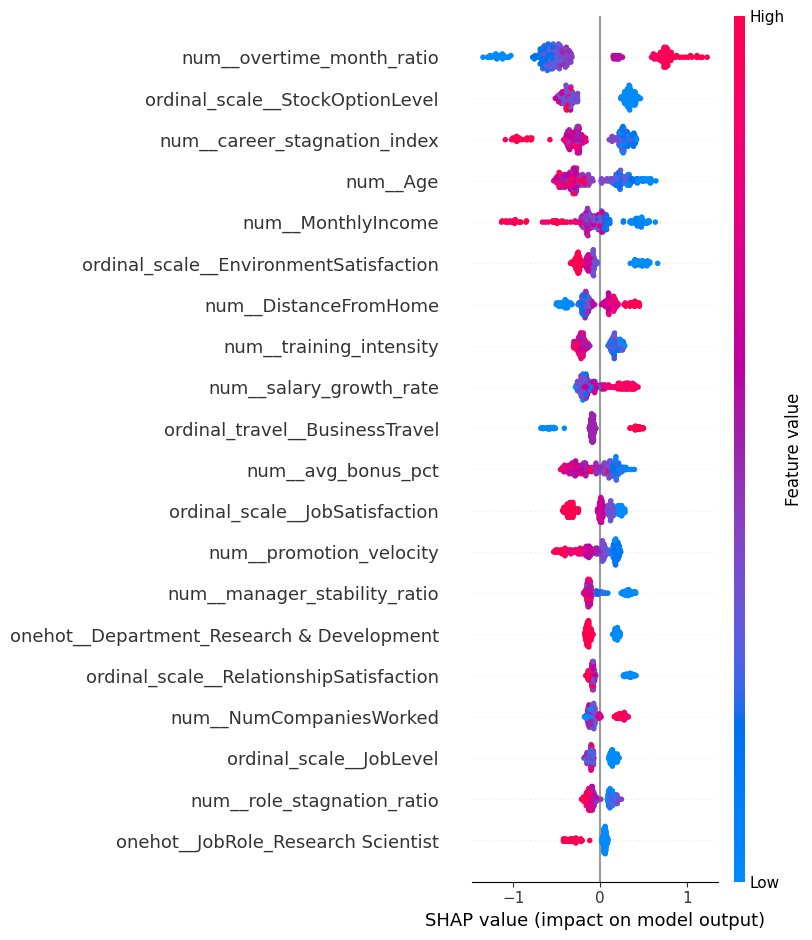

In [9]:
# Extract the fitted XGBoost model from the pipeline
xgb_model = model.named_steps['classifier']

# Transform X_test through the preprocessor only
X_test_transformed = model.named_steps['preprocessor'].transform(X_test)

# Get feature names from preprocessor
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_transformed)

# Summary plot
shap.summary_plot(
    shap_values, 
    X_test_transformed, 
    feature_names=feature_names,
    max_display=20
)

In [10]:
# Get mean absolute SHAP values for all features
shap_importance = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print(shap_importance)
print(f"\nFeatures with near-zero SHAP (<0.01): {(shap_importance['mean_abs_shap'] < 0.01).sum()}")

                                      feature  mean_abs_shap
31                  num__overtime_month_ratio       0.631917
19            ordinal_scale__StockOptionLevel       0.362683
33               num__career_stagnation_index       0.341572
20                                   num__Age       0.303900
23                         num__MonthlyIncome       0.242458
14     ordinal_scale__EnvironmentSatisfaction       0.228537
21                      num__DistanceFromHome       0.210817
37                    num__training_intensity       0.201238
29                    num__salary_growth_rate       0.196954
12             ordinal_travel__BusinessTravel       0.196821
32                         num__avg_bonus_pct       0.188412
15             ordinal_scale__JobSatisfaction       0.179249
34                    num__promotion_velocity       0.171919
36               num__manager_stability_ratio       0.162288
0   onehot__Department_Research & Development       0.155209
18    ordinal_scale__Rel